# BERTopic: Topic Shift in Outage Coverage (Pre-AI vs Post-AI)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import spacy
import warnings
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
warnings.filterwarnings("ignore")

nlp = spacy.load("en_core_web_sm")

df_all = pd.read_csv("merged_relevant_articles.csv")
df_all["pub_date"] = pd.to_datetime(df_all["pub_date"], utc=True, errors="coerce")

df_gd = df_all[(df_all["source"] == "guardian") & (df_all["has_full_text"] == True)].copy()
for col in ["text_for_analysis", "full_text", "text"]:
    if col in df_gd.columns:
        df_gd["text_for_analysis"] = df_gd[col]
        break
df_gd = df_gd.dropna(subset=["text_for_analysis"]).reset_index(drop=True)
df = df_gd

---
## Preprocessing


In [2]:
# Sentence-aware chunking + lemmatization

def sentence_chunk(text, nlp, target_size=200, min_chunk_words=30):
    """
    Split text into chunks at sentence boundaries (~target_size words each).
    Returns list of (raw_chunk, lemmatized_chunk) tuples.
    """
    doc = nlp(str(text))
    sentences = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 5]

    chunks = []
    current_sents = []
    current_len = 0

    for sent in sentences:
        word_count = len(sent.split())
        if current_len + word_count > target_size and current_len >= min_chunk_words:
            chunks.append(" ".join(current_sents))
            current_sents = [sent]
            current_len = word_count
        else:
            current_sents.append(sent)
            current_len += word_count

    if current_len >= min_chunk_words:
        chunks.append(" ".join(current_sents))
    elif current_sents and chunks:
        chunks[-1] += " " + " ".join(current_sents)
    elif current_sents:
        chunks.append(" ".join(current_sents))

    return chunks


def lemmatize(text, nlp):
    """Lemmatize text, keeping only content words (NOUN, VERB, ADJ, ADV)."""
    doc = nlp(str(text))
    tokens = [
        tok.lemma_.lower() for tok in doc
        if tok.pos_ in ("NOUN", "VERB", "ADJ", "ADV")
        and not tok.is_stop and not tok.is_punct
        and len(tok.lemma_) > 2 and tok.lemma_.isalpha()
    ]
    return " ".join(tokens)

chunk_rows = []

for idx, row in df.iterrows():
    chunks = sentence_chunk(row["text_for_analysis"], nlp)
    for ci, chunk in enumerate(chunks):
        chunk_rows.append({
            "doc_id": idx, "chunk_id": ci,
            "text": chunk,
            "text_lemmatized": lemmatize(chunk, nlp),
            "era": row["era"], "event": row["event"],
        })

chunk_df = pd.DataFrame(chunk_rows)

---
## Configure & Fit Single BERTopic Model

One model on all chunks. The transformer embeds full-text. The c-TF-IDF vectorizer operates on lemmatized text (cleaner topic keywords)


In [3]:
# Embedding: raw text -> 768-dim vectors
embedding_model = SentenceTransformer("all-mpnet-base-v2")

umap_model = UMAP(
    n_neighbors=15, n_components=5,
    min_dist=0.0, metric="cosine", random_state=42,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=15, min_samples=5,
    metric="euclidean", prediction_data=True,
)

# Vectorizer on LEMMATIZED text with domain stopwords - AI assisted
domain_stops = [
    "said", "would", "also", "could", "people", "new", "like",
    "time", "year", "just", "know", "way", "think", "even", "get",
    "going", "say", "says", "told", "make", "much", "many", "well",
    "back", "still", "good", "last", "first", "two", "made", "need",
    "come", "want", "take", "thing", "week", "day", "month",
    "mr", "ms", "according", "guardian", "one",
]

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
all_stops = list(ENGLISH_STOP_WORDS | set(domain_stops))

vectorizer = CountVectorizer(
    ngram_range=(1, 2), stop_words=all_stops,
    min_df=3, max_df=0.85,
)

# Encode all chunks (raw text)
all_texts = chunk_df["text"].tolist()
all_embeddings = embedding_model.encode(all_texts, show_progress_bar=True, batch_size=32)
print(f"Embeddings: {all_embeddings.shape}")
model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    top_n_words=10,
    verbose=True,
)

# Use lemmatized text for c-TF-IDF (better keywords), raw embeddings for clustering
all_lemmatized = chunk_df["text_lemmatized"].tolist()
topics, probs = model.fit_transform(all_lemmatized, all_embeddings)

chunk_df["topic"] = topics
topic_info = model.get_topic_info()
n_topics = len(topic_info[topic_info["Topic"] != -1])
n_noise = topic_info[topic_info["Topic"] == -1]["Count"].values[0]
print(f"\n{n_topics} topics discovered, {n_noise} noise chunks ({100*n_noise/len(all_texts):.0f}%)")
topic_info.head(15)


Batches:   0%|          | 0/50 [00:00<?, ?it/s]

2026-03-08 16:23:50,135 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Embeddings: (1591, 768)


2026-03-08 16:23:54,953 - BERTopic - Dimensionality - Completed ✓
2026-03-08 16:23:54,954 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-08 16:23:54,972 - BERTopic - Cluster - Completed ✓
2026-03-08 16:23:54,976 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-03-08 16:23:55,133 - BERTopic - Representation - Completed ✓



32 topics discovered, 154 noise chunks (10%)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,154,-1_water_wedding_love_service,"[water, wedding, love, service, use, governmen...",[say efficiency saving achieve point company c...
1,0,337,0_company_content_platform_user,"[company, content, platform, user, social, med...",[bring document forward come light news report...
2,1,126,1_president_sign_report_government,"[president, sign, report, government, state, p...",[baseballer rank sixth world pull final qualif...
3,2,78,2_bank_cash_rise_spending,"[bank, cash, rise, spending, budget, price, sp...",[chief economist say low borrowing expect leav...
4,3,64,3_climate_crisis_climate crisis_activist,"[climate, crisis, climate crisis, activist, pl...",[charge country violate right child take suffi...
5,4,63,4_read review_review_film_read,"[read review, review, film, read, theatre, sta...",[nickel novel intensely move story friend trap...
6,5,54,5_company_tech_earning_student,"[company, tech, earning, student, tool, market...",[blow concern overspend report elevate earning...
7,6,51,6_flight_airport_airline_passenger,"[flight, airport, airline, passenger, affect, ...",[passenger describe airport check global outag...
8,7,45,7_update_software_outage_cybersecurity,"[update, software, outage, cybersecurity, fix,...",[primary cause failure stem update push flagsh...
9,8,44,8_woman_man_health_datum,"[woman, man, health, datum, tracking, app, dat...",[especially draw look height prefer know devel...


---
## Topic Shift: Pre-AI vs Post-AI

Using BERTopic's `topics_per_class` to compare how topic prevalence changes across eras.


In [8]:
import numpy as np

chunk_df["prob"] = probs.max(axis=1) if probs.ndim == 2 else probs

# For each (era, topic) pair, sum the probabilities instead of counting chunks
weighted = (
    chunk_df[chunk_df["topic"] != -1]
    .groupby(["era", "topic"])["prob"]
    .sum()
    .unstack(fill_value=0)
)

weighted_pct = weighted.div(weighted.sum(axis=1), axis=0) * 100
weighted_pct = weighted_pct.reindex(["pre_ai", "post_ai"], fill_value=0)

print("Probability-weighted topic distribution by era (%):")
display(weighted_pct.round(1))

# BERTopic's built-in topics_per_class (count-based)
classes = chunk_df["era"].tolist()
topics_per_class = model.topics_per_class(all_lemmatized, classes=classes)
fig = model.visualize_topics_per_class(topics_per_class, top_n_topics=10)
fig.show()


Probability-weighted topic distribution by era (%):


topic,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
era,,,,,,,,,,,,,,,,,,,,,
pre_ai,44.6,9.6,5.3,6.7,1.7,0.1,0.1,0.1,3.6,2.9,...,2.9,2.4,0.0,0.6,2.4,0.1,0.0,1.0,0.0,0.0
post_ai,2.1,6.0,6.8,0.8,6.2,8.3,6.6,6.1,3.0,1.8,...,0.1,0.2,3.2,2.7,0.0,2.6,2.9,1.6,2.9,2.9


2it [00:00, 24.01it/s]


Topic shift (probability-weighted, normalized by era size):


,pre_ai_%,post_ai_%,shift,pre_n,post_n,keywords
5,0.1,8.3,8.2,1,53,"company, tech, earning, student"
6,0.1,6.6,6.5,1,50,"flight, airport, airline, passenger"
7,0.1,6.1,6.1,1,44,"update, software, outage, cybersecurity"
13,0.1,4.6,4.5,1,31,"student, school, raid, immigrant"
4,1.7,6.2,4.5,21,42,"read review, review, film, read"
11,0.0,4.2,4.2,0,33,"man, mushroom, death, driver"
12,0.1,4.2,4.1,1,32,"ball, wicket, win, game"
18,0.0,3.5,3.5,0,29,"israeli, worker, military, tech"
14,0.6,4.1,3.4,6,26,"cloud, service, outage, computing"
24,0.0,3.2,3.2,0,19,"family, travel, father, husband"


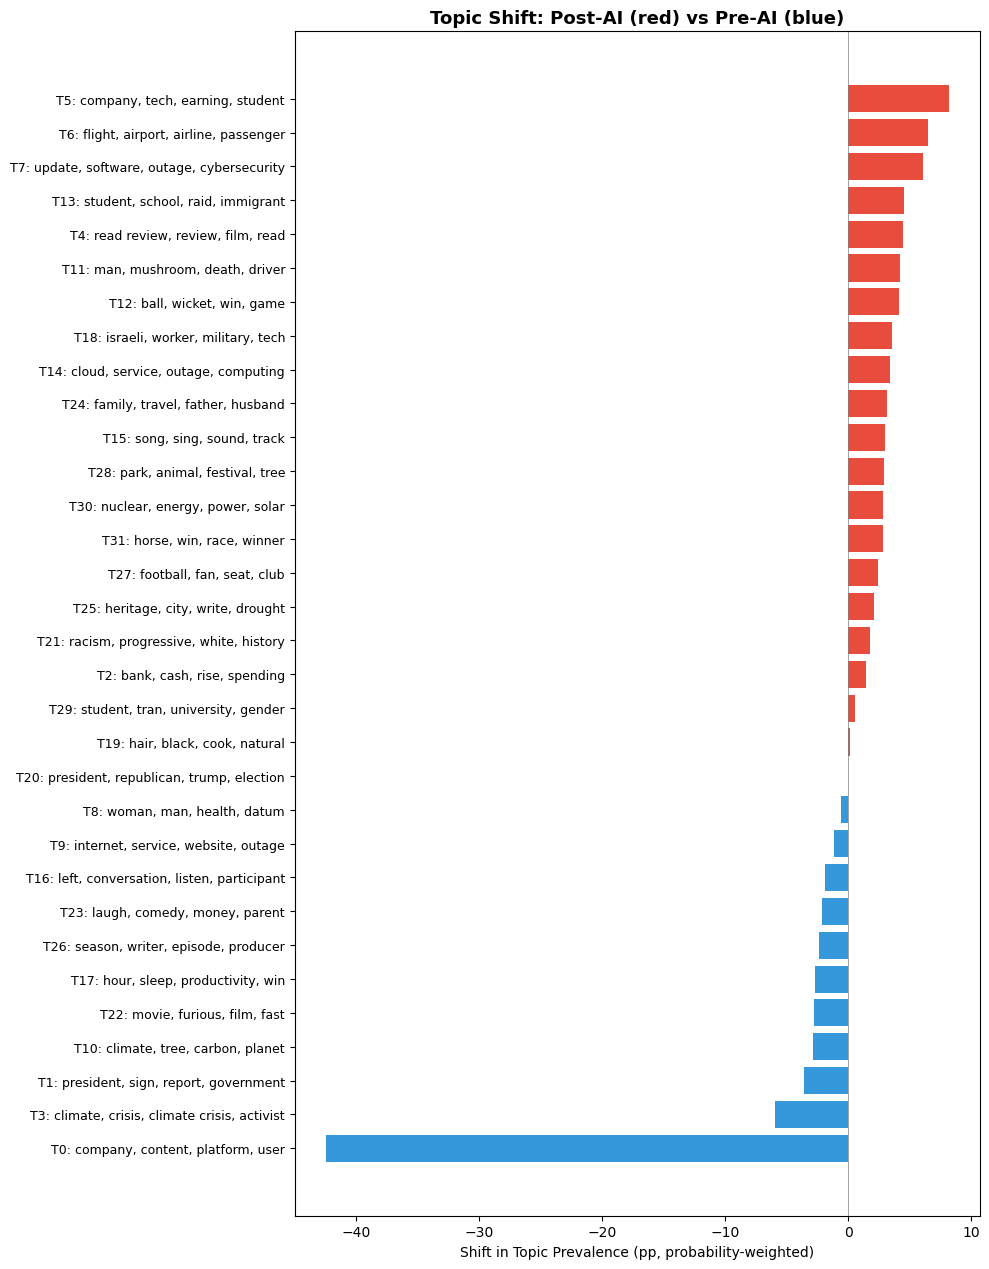

In [9]:
# Topic shift: probability-weighted, normalized by era

# Get all non-noise topics
all_topic_ids = sorted([c for c in weighted_pct.columns if c != -1])

comparison = pd.DataFrame({
    "pre_ai_%": weighted_pct.loc["pre_ai", all_topic_ids].values,
    "post_ai_%": weighted_pct.loc["post_ai", all_topic_ids].values,
}, index=all_topic_ids)

comparison["shift"] = comparison["post_ai_%"] - comparison["pre_ai_%"]
comparison["keywords"] = [
    ", ".join([w for w, _ in model.get_topic(t)][:4]) for t in all_topic_ids
]
comparison = comparison.sort_values("shift", ascending=False)

# Also add raw chunk counts for context
pre_non_noise = chunk_df[(chunk_df["era"] == "pre_ai") & (chunk_df["topic"] != -1)]
post_non_noise = chunk_df[(chunk_df["era"] == "post_ai") & (chunk_df["topic"] != -1)]
comparison["pre_n"] = [len(pre_non_noise[pre_non_noise["topic"] == t]) for t in comparison.index]
comparison["post_n"] = [len(post_non_noise[post_non_noise["topic"] == t]) for t in comparison.index]

print("Topic shift (probability-weighted, normalized by era size):")
display(comparison[["pre_ai_%", "post_ai_%", "shift", "pre_n", "post_n", "keywords"]].round(1))

fig, ax = plt.subplots(figsize=(10, max(6, len(comparison) * 0.4)))
labels = [f"T{t}: {comparison.loc[t, 'keywords']}" for t in comparison.index]
colors = ["#e74c3c" if s > 0 else "#3498db" for s in comparison["shift"]]
ax.barh(range(len(labels)), comparison["shift"].values, color=colors)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Shift in Topic Prevalence (pp, probability-weighted)")
ax.set_title("Topic Shift: Post-AI (red) vs Pre-AI (blue)", fontsize=13, fontweight="bold")
ax.axvline(0, color="gray", linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


---
## Document-Level Aggregation


In [10]:
def aggregate_doc_topics_weighted(chunk_df):
    """Assign each document the topic with highest summed probability."""
    results = {}
    for doc_id, group in chunk_df.groupby("doc_id"):
        non_noise = group[group["topic"] != -1]
        if non_noise.empty:
            results[doc_id] = -1
            continue
        # Sum probability per topic across chunks
        topic_weights = non_noise.groupby("topic")["prob"].sum()
        results[doc_id] = topic_weights.idxmax()
    return pd.Series(results, name="topic")

doc_topics = aggregate_doc_topics_weighted(chunk_df)
chunk_df_doc = chunk_df.drop_duplicates("doc_id").set_index("doc_id")[["era", "event"]].copy()
chunk_df_doc["topic"] = doc_topics

# Normalized distribution by era
print("Document-level topic distribution by era (%):")
doc_dist = pd.crosstab(chunk_df_doc["era"], chunk_df_doc["topic"], normalize="index") * 100
display(doc_dist.reindex(["pre_ai", "post_ai"]).round(1))

# Document-level shift
doc_all_topics = sorted([c for c in doc_dist.columns if c != -1])
doc_comparison = pd.DataFrame({
    "pre_ai_%": doc_dist.reindex(["pre_ai"]).values.flatten()[:len(doc_dist.columns)],
    "post_ai_%": doc_dist.reindex(["post_ai"]).values.flatten()[:len(doc_dist.columns)],
}, index=doc_dist.columns)
doc_comparison = doc_comparison.drop(-1, errors="ignore")
doc_comparison["shift"] = doc_comparison["post_ai_%"] - doc_comparison["pre_ai_%"]
doc_comparison["keywords"] = [
    ", ".join([w for w, _ in model.get_topic(t)][:4]) if t != -1 else "noise"
    for t in doc_comparison.index
]
doc_comparison = doc_comparison.sort_values("shift", ascending=False)

print("\nDocument-level topic shift:")
display(doc_comparison.round(1))


Document-level topic distribution by era (%):


topic,-1,0,1,2,3,4,5,6,7,8,...,22,23,24,25,26,27,28,29,30,31
era,,,,,,,,,,,,,,,,,,,,,
pre_ai,6.5,46.4,13.0,5.8,2.9,2.9,0.0,0.0,0.0,1.4,...,1.4,0.7,0.0,0.0,0.7,0.0,0.0,0.7,0.0,0.0
post_ai,3.8,1.5,7.6,7.6,0.0,4.6,9.2,9.2,11.5,2.3,...,0.0,0.0,0.8,1.5,0.0,1.5,2.3,0.8,3.1,1.5



Document-level topic shift:


,pre_ai_%,post_ai_%,shift,keywords
topic,,,,
7,0.0,11.5,11.5,"update, software, outage, cybersecurity"
5,0.0,9.2,9.2,"company, tech, earning, student"
6,0.0,9.2,9.2,"flight, airport, airline, passenger"
12,0.0,5.3,5.3,"ball, wicket, win, game"
11,0.0,5.3,5.3,"man, mushroom, death, driver"
14,1.4,5.3,3.9,"cloud, service, outage, computing"
13,0.0,3.8,3.8,"student, school, raid, immigrant"
30,0.0,3.1,3.1,"nuclear, energy, power, solar"
28,0.0,2.3,2.3,"park, animal, festival, tree"


---
## BERTopic Visualizations


In [11]:
# Topic barchart
model.visualize_barchart(top_n_topics=10).show()

# Intertopic distance
model.visualize_topics().show()

# Hierarchy
model.visualize_hierarchy().show()
